# Channel Verification — Rogala Lab
Use this notebook to visually inspect images and confirm which channel is DAPI, LAMP1, and Raptor.

**Before running the analysis pipeline, verify:**
- C0 → DAPI (nuclei, bright ovals)
- C1 → LAMP1 (lysosomes, scattered puncta)
- C2 → Raptor (more diffuse cytoplasmic + puncta)

If the order is wrong, update `--ch_dapi / --ch_lamp1 / --ch_marker` in `ingest.py`.

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import glob
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Ready')

Ready


## 1. Point to your image folder

In [2]:
# ── EDIT THIS ─────────────────────────────────────────────────────────────────
IMAGE_DIR = "/Users/vaishnavinagesh/Google Drive/My Drive/Confocal/080326"

# Expected channel numbers — change if you think they might be different
CH_DAPI   = 0
CH_LAMP1  = 1
CH_MARKER = 2

MARKER_NAME = 'Raptor'
# ──────────────────────────────────────────────────────────────────────────────

# Find all tif files
all_tifs = sorted(glob.glob(f"{IMAGE_DIR}/**/*.tif", recursive=True) + 
                  glob.glob(f"{IMAGE_DIR}/*.tif"))
print(f"Found {len(all_tifs)} .tif files")
print(f"First few:")
for f in all_tifs[:5]:
    print(f"  {Path(f).name}")

Found 222 .tif files
First few:
  AA+_10uM6698_C1_XY1785628273_Z00_T0_C0.tif
  AA+_10uM6698_C1_XY1785628273_Z00_T0_C0.tif
  AA+_10uM6698_C1_XY1785628273_Z00_T0_C1.tif
  AA+_10uM6698_C1_XY1785628273_Z00_T0_C1.tif
  AA+_10uM6698_C1_XY1785628273_Z00_T0_C2.tif


## 2. Find one complete triplet (C0, C1, C2) to inspect

In [3]:
import re
from collections import defaultdict

CH_RE = re.compile(r'_C(\d)\.tif$', re.IGNORECASE)

# Group by stem (everything before _C{n}.tif)
stems = defaultdict(dict)
for f in all_tifs:
    m = CH_RE.search(Path(f).name)
    if m:
        ch   = int(m.group(1))
        stem = f[:f.rfind('_C')]
        stems[stem][ch] = f

# Find triplets that have all three channels
triplets = {s: chs for s, chs in stems.items() 
            if all(ch in chs for ch in [CH_DAPI, CH_LAMP1, CH_MARKER])}

print(f"Found {len(triplets)} complete triplets")
print("\nAvailable triplets:")
for i, stem in enumerate(sorted(triplets.keys())):
    print(f"  [{i}] {Path(stem).name}")

Found 37 complete triplets

Available triplets:
  [0] AA+_10uM6698_C1_XY1785628273_Z00_T0
  [1] AA+_10uM6698_C2_XY1785628549_Z00_T0
  [2] AA+_10uM6698_C3_XY1785628771_Z00_T0
  [3] AA+_20nMRapa_C1_XY1785629851_Z00_T0
  [4] AA+_20nMRapa_C2_XY1785630105_Z00_T0
  [5] AA+_20nMRapa_C3 - 1_XY1785630432_Z00_T0
  [6] AA+_20uM6698_C1_XY1785629079_Z00_T0
  [7] AA+_20uM6698_C2_XY1785629330_Z00_T0
  [8] AA+_20uM6698_C3_XY1785629569_Z00_T0
  [9] AA+_250nMAZD_C1_XY1785630709_Z00_T0
  [10] AA+_250nMAZD_C2_XY1785630830_Z00_T0
  [11] AA+_250nMAZD_C3_XY1785630999_Z00_T0
  [12] AA+_5uM6698_C1_XY1785627244_Z00_T0
  [13] AA+_5uM6698_C2_XY1785627478_Z00_T0
  [14] AA+_5uM6698_C3_XY1785627810_Z00_T0
  [15] AA+_DMSO_C1_XY1785626518_Z00_T0
  [16] AA+_DMSO_C2_XY1785626766_Z00_T0
  [17] AA+_DMSO_C3_XY1785626960_Z00_T0
  [18] AA-_10uM6698_C1_XY1785631702_Z00_T0
  [19] AA-_10uM6698_C2_XY1785631836_Z00_T0
  [20] AA-_10uM6698_C3_XY1785632071_Z00_T0
  [21] AA-_20nMRapa_C1_XY1785725927_Z00_T0
  [22] AA-_20nMRapa_C2_XY17

In [4]:
# ── Pick which triplet to inspect ─────────────────────────────────────────────
TRIPLET_IDX = 0   # Change this to inspect different conditions
# ──────────────────────────────────────────────────────────────────────────────

stem   = sorted(triplets.keys())[TRIPLET_IDX]
paths  = triplets[stem]

print(f"Inspecting: {Path(stem).name}")
for ch, path in sorted(paths.items()):
    print(f"  C{ch}: {Path(path).name}")

Inspecting: AA+_10uM6698_C1_XY1785628273_Z00_T0
  C0: AA+_10uM6698_C1_XY1785628273_Z00_T0_C0.tif
  C1: AA+_10uM6698_C1_XY1785628273_Z00_T0_C1.tif
  C2: AA+_10uM6698_C1_XY1785628273_Z00_T0_C2.tif


## 3. Load and inspect each channel

In [5]:
def load_best_z(path):
    """Load TIFF and return the sharpest z-plane (max variance)."""
    stack = tifffile.imread(path).astype(np.float32)
    if stack.ndim == 3:
        variances = [np.var(stack[z]) for z in range(stack.shape[0])]
        best = np.argmax(variances)
        print(f"  Shape: {stack.shape} | Best z-plane: {best}/{stack.shape[0]}")
        return stack[best]
    print(f"  Shape: {stack.shape} (2D)")
    return stack

def norm(img, plow=1, phigh=99.5):
    lo, hi = np.percentile(img, plow), np.percentile(img, phigh)
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

print("Loading C0:")
c0 = load_best_z(paths[CH_DAPI])
print("Loading C1:")
c1 = load_best_z(paths[CH_LAMP1])
print("Loading C2:")
cm = load_best_z(paths[CH_MARKER])
print("Done")

Loading C0:
  Shape: (60, 2048, 2048) | Best z-plane: 53/60
Loading C1:
  Shape: (60, 2048, 2048) | Best z-plane: 56/60
Loading C2:
  Shape: (60, 2048, 2048) | Best z-plane: 56/60
Done


## 4. View all channels side by side

**What to look for:**
- **DAPI**: bright oval/round shapes = nuclei. Should be very clear nuclear morphology.
- **LAMP1**: scattered bright dots (puncta) throughout the cytoplasm. More concentrated = more lysosomes.
- **Raptor**: mix of diffuse cytoplasmic signal + some brighter puncta.

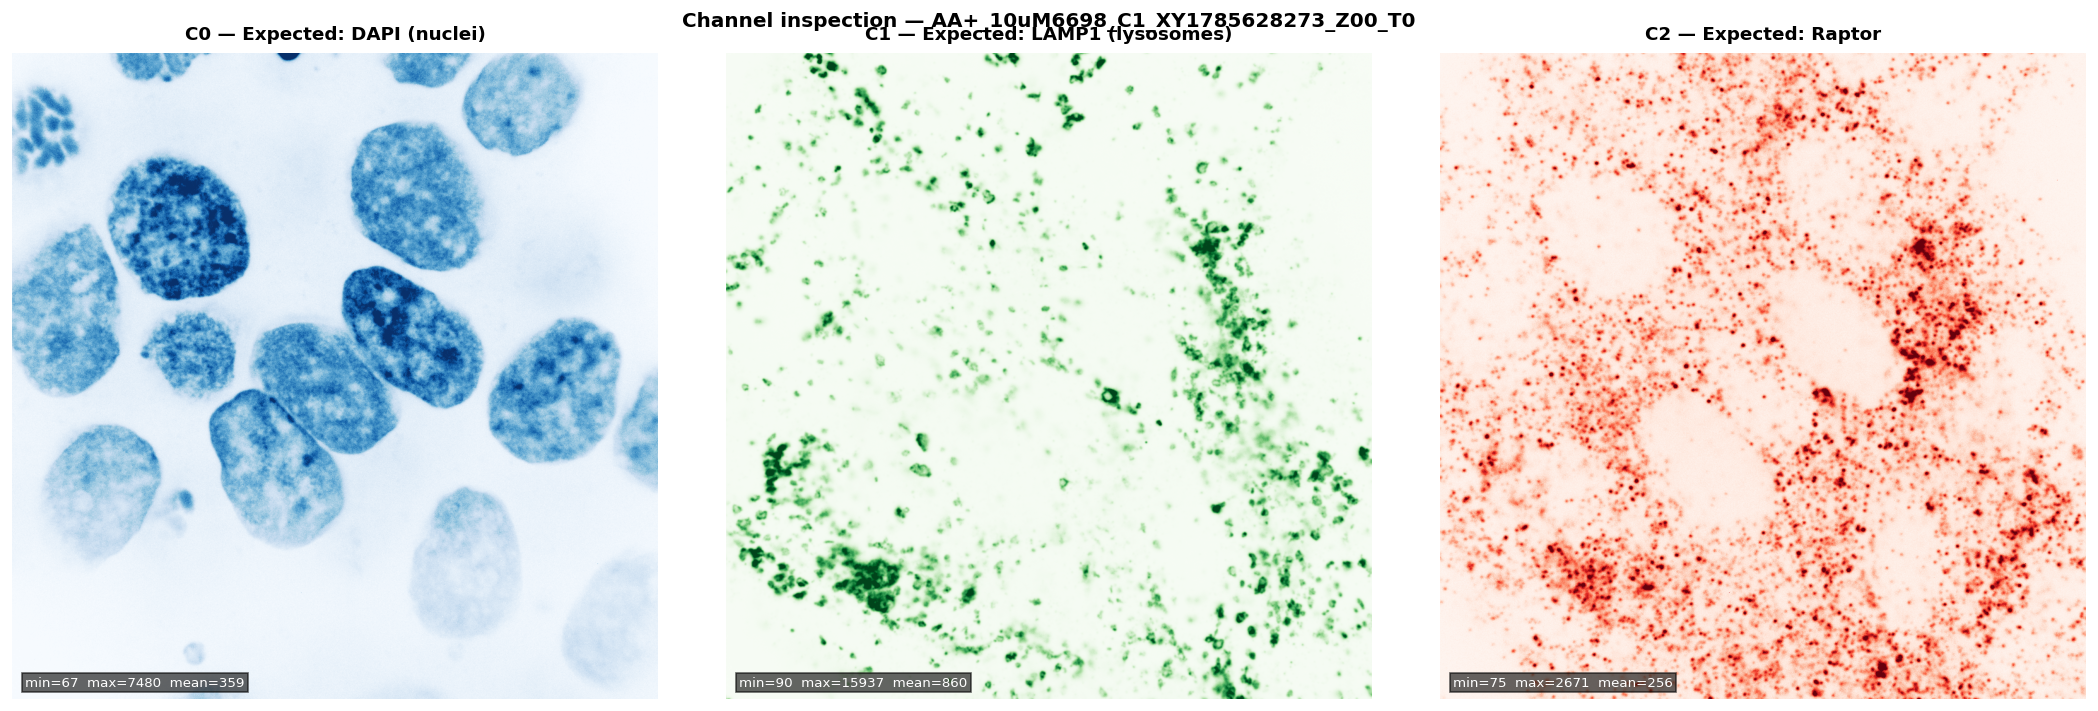


✓ If C0 shows oval nuclei → DAPI assignment correct
✓ If C1 shows scattered bright dots → LAMP1 assignment correct
✓ If C2 shows diffuse + puncta pattern → Raptor assignment correct

If wrong, swap the CH_DAPI / CH_LAMP1 / CH_MARKER values at the top of Cell 2


In [6]:
# Crop center for faster display
H, W = c0.shape
S = 512
sl = np.s_[H//2-S:H//2+S, W//2-S:W//2+S]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Channel inspection — {Path(stem).name}', fontsize=12, fontweight='bold')

channels = [
    (c0[sl], f'C{CH_DAPI} — Expected: DAPI (nuclei)', 'Blues'),
    (c1[sl], f'C{CH_LAMP1} — Expected: LAMP1 (lysosomes)', 'Greens'),
    (cm[sl], f'C{CH_MARKER} — Expected: {MARKER_NAME}', 'Reds'),
]

for ax, (img, title, cmap) in zip(axes, channels):
    ax.imshow(norm(img), cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')
    # Intensity stats
    ax.text(0.02, 0.02, 
            f'min={img.min():.0f}  max={img.max():.0f}  mean={img.mean():.0f}',
            transform=ax.transAxes, color='white', fontsize=8,
            bbox=dict(facecolor='black', alpha=0.6, pad=2))

plt.tight_layout()
plt.show()

print()
print("✓ If C0 shows oval nuclei → DAPI assignment correct")
print("✓ If C1 shows scattered bright dots → LAMP1 assignment correct") 
print("✓ If C2 shows diffuse + puncta pattern → Raptor assignment correct")
print()
print("If wrong, swap the CH_DAPI / CH_LAMP1 / CH_MARKER values at the top of Cell 2")

## 5. Zoom into a single cell for detailed inspection

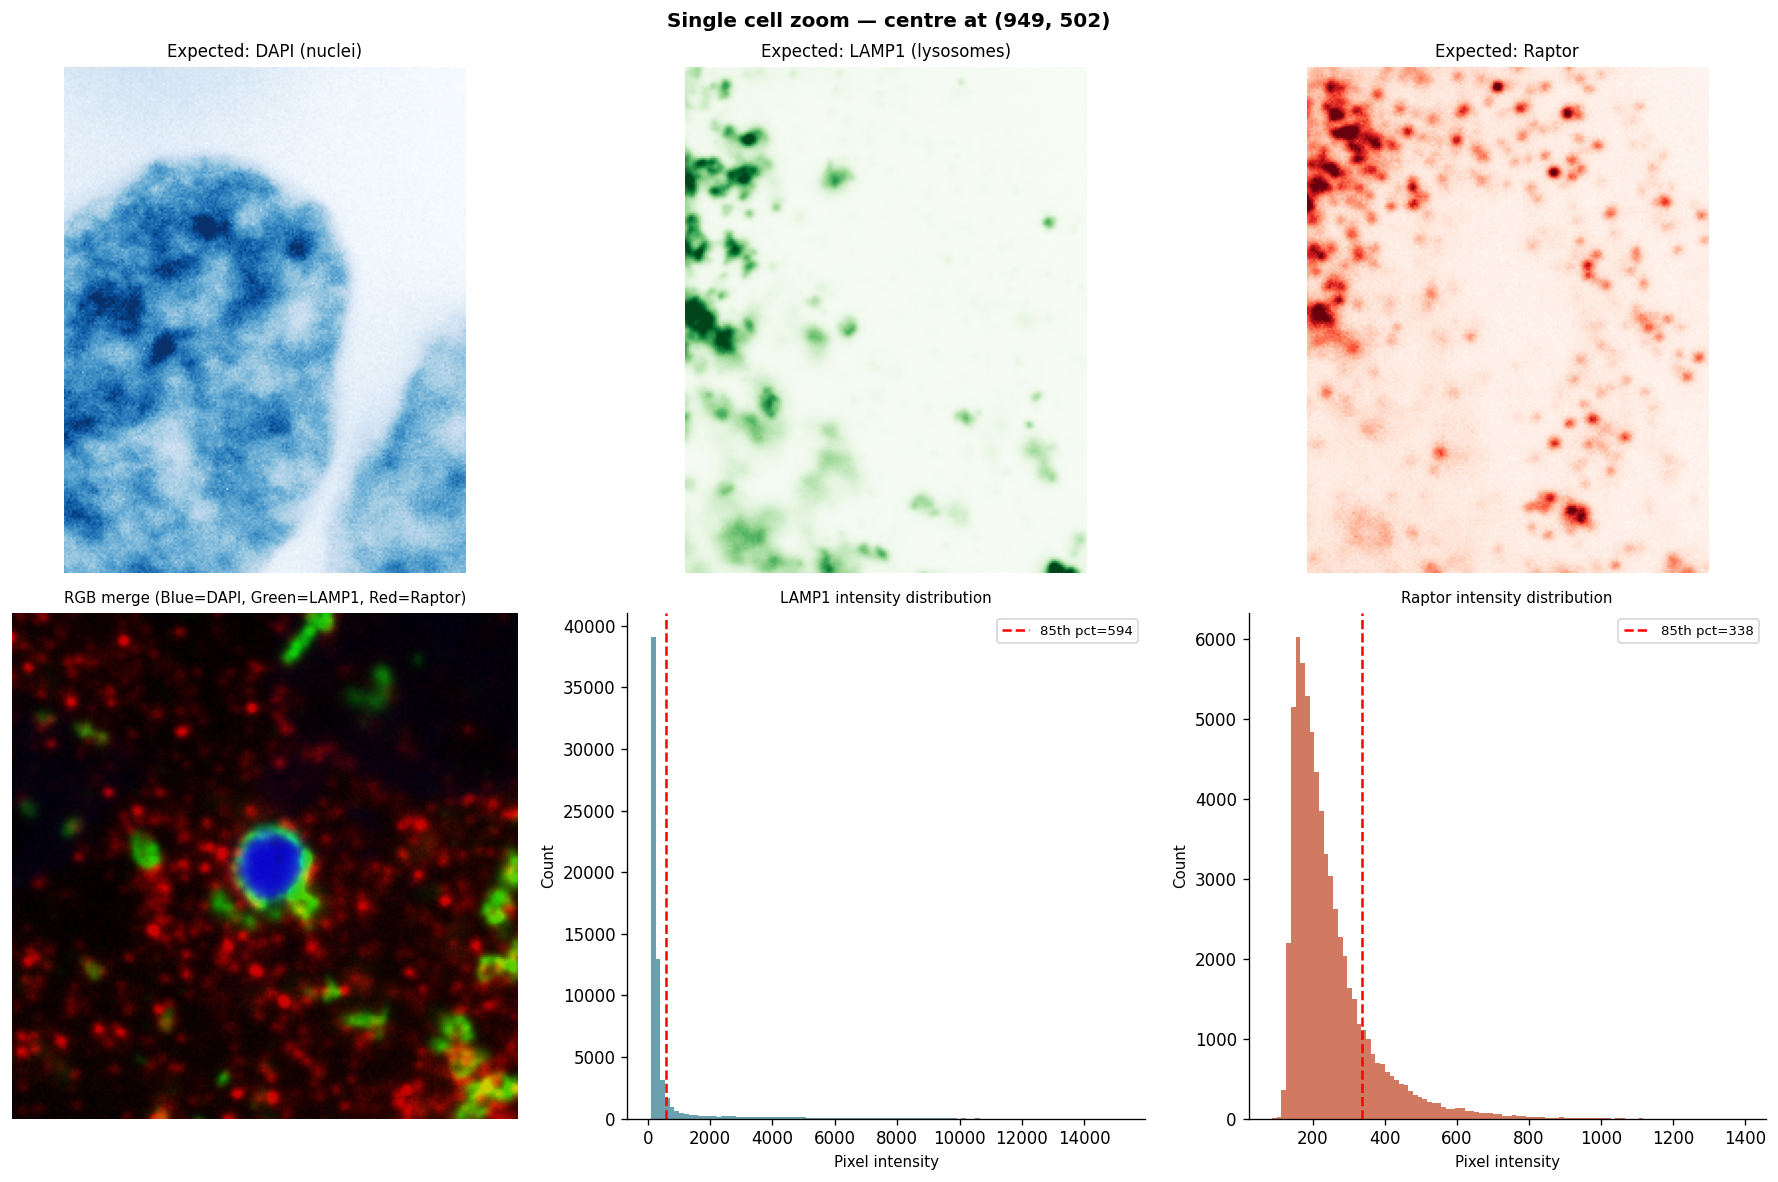

In [7]:
# Find brightest region in DAPI (likely a cell)
from skimage.filters import gaussian
from skimage.feature import peak_local_max

dapi_smooth = gaussian(c0, sigma=5)
# Find peak (nucleus centre)
peak = np.unravel_index(dapi_smooth.argmax(), dapi_smooth.shape)
py, px = peak

# Crop 256x256 around that cell
Z = 128
y0, y1 = max(0, py-Z), min(H, py+Z)
x0, x1 = max(0, px-Z), min(W, px+Z)
cell_sl = np.s_[y0:y1, x0:x1]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Single cell zoom — centre at ({px}, {py})', fontsize=12, fontweight='bold')

# Row 1: individual channels
for ax, (img, title, cmap) in zip(axes[0], channels):
    ax.imshow(norm(img[cell_sl]), cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title.split('—')[1].strip(), fontsize=10)
    ax.axis('off')

# Row 2: RGB merge + histogram
rgb = np.zeros((*c0[cell_sl].shape, 3))
rgb[:,:,2] = norm(c0[cell_sl]) * 0.8   # DAPI = blue
rgb[:,:,1] = norm(c1[cell_sl]) * 0.8   # LAMP1 = green  
rgb[:,:,0] = norm(cm[cell_sl]) * 0.8   # Marker = red
axes[1,0].imshow(np.clip(rgb, 0, 1))
axes[1,0].set_title('RGB merge (Blue=DAPI, Green=LAMP1, Red=Raptor)', fontsize=9)
axes[1,0].axis('off')

# Histograms
for ax, (img, label, col) in zip(axes[1,1:], [
    (c1[cell_sl], 'LAMP1 intensity distribution', '#2C7A8C'),
    (cm[cell_sl], f'{MARKER_NAME} intensity distribution', '#C04020'),
]):
    ax.hist(img.flatten(), bins=100, color=col, alpha=0.7, edgecolor='none')
    ax.set_xlabel('Pixel intensity', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Mark 85th percentile
    p85 = np.percentile(img, 85)
    ax.axvline(p85, color='red', linestyle='--', linewidth=1.5, label=f'85th pct={p85:.0f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Compare the same condition across all channels — whole image

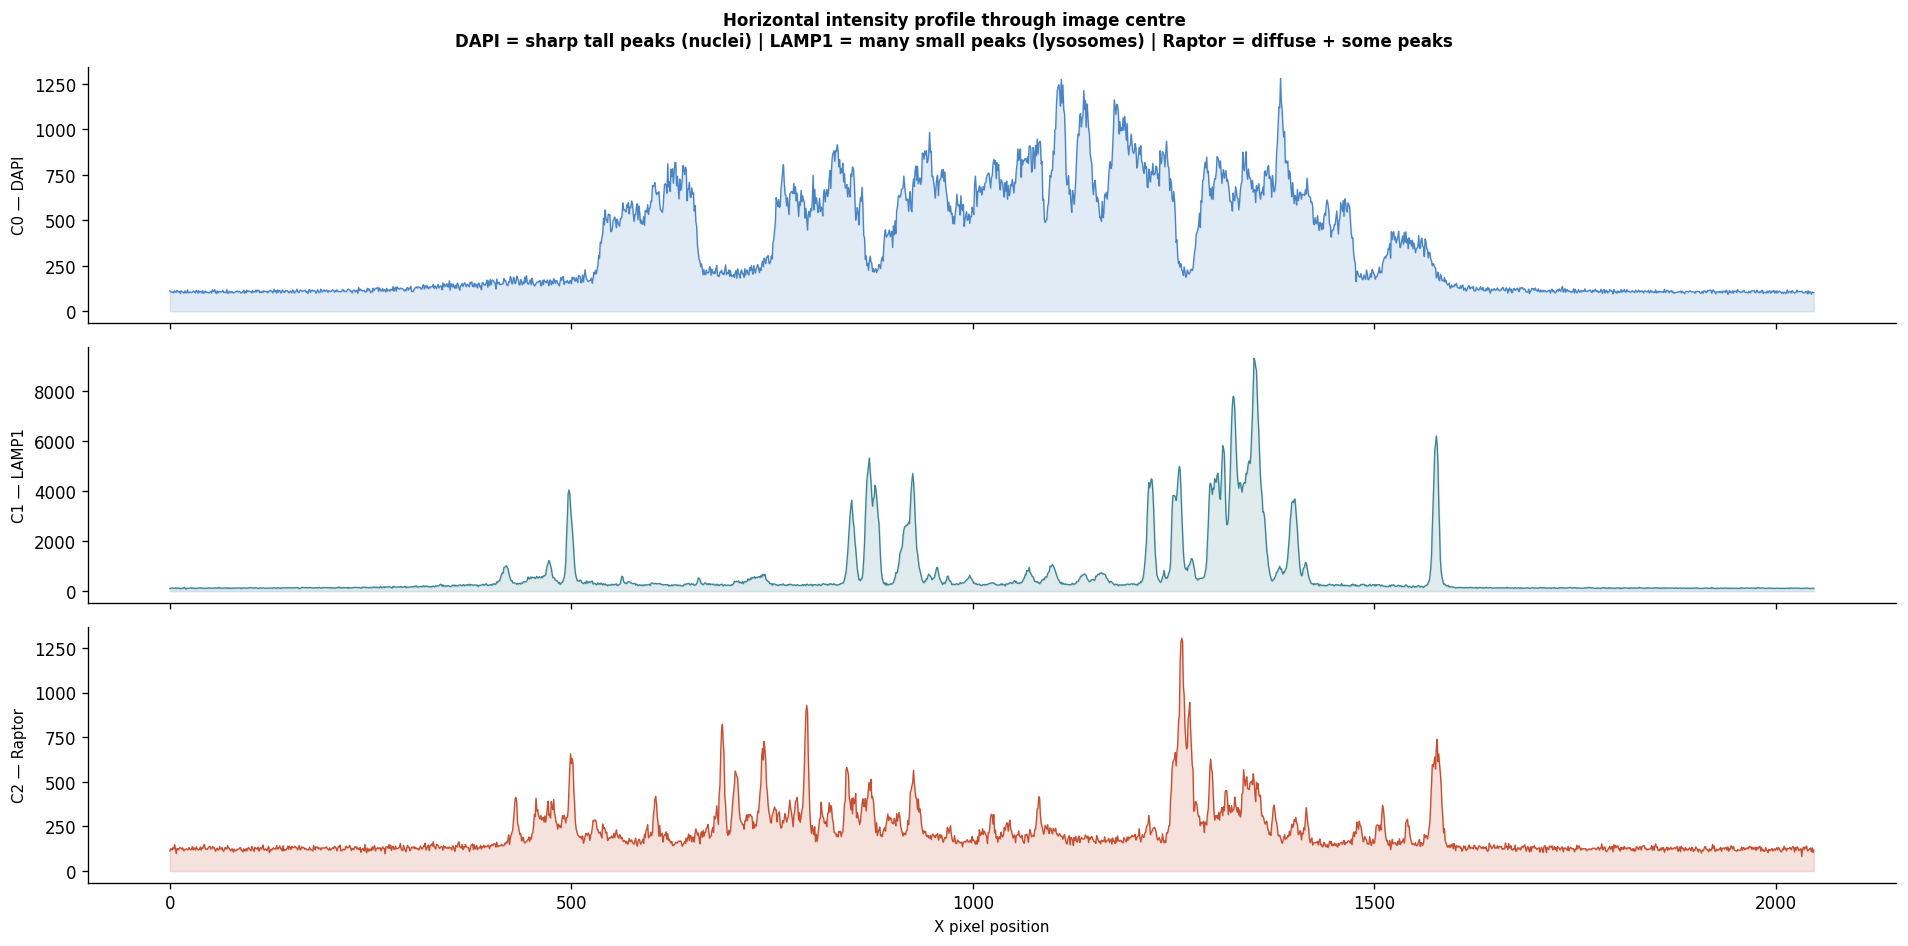


Interpretation guide:
  DAPI: should show 3-5 large sharp peaks = nuclei
  LAMP1: should show many small peaks scattered between nuclei
  Raptor: higher baseline with some peaks = diffuse + puncta


In [8]:
# Show intensity profiles to confirm channel identity
# DAPI should show clear peaks at nucleus locations
# LAMP1 should show scattered smaller peaks (puncta)
# Raptor should show broader, more diffuse profile

# Take a horizontal line through the middle
mid_row = H // 2
x_vals  = np.arange(W)

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Horizontal intensity profile through image centre\n'
             'DAPI = sharp tall peaks (nuclei) | '
             'LAMP1 = many small peaks (lysosomes) | '
             'Raptor = diffuse + some peaks',
             fontsize=10, fontweight='bold')

profiles = [
    (c0[mid_row, :], f'C{CH_DAPI} — DAPI',   '#3A7ABF'),
    (c1[mid_row, :], f'C{CH_LAMP1} — LAMP1',  '#2C7A8C'),
    (cm[mid_row, :], f'C{CH_MARKER} — {MARKER_NAME}', '#C04020'),
]

for ax, (profile, label, color) in zip(axes, profiles):
    ax.plot(x_vals, profile, color=color, linewidth=0.8, alpha=0.9)
    ax.fill_between(x_vals, 0, profile, color=color, alpha=0.15)
    ax.set_ylabel(label, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('X pixel position', fontsize=9)
plt.tight_layout()
plt.show()

print("\nInterpretation guide:")
print("  DAPI: should show 3-5 large sharp peaks = nuclei")
print("  LAMP1: should show many small peaks scattered between nuclei")
print("  Raptor: higher baseline with some peaks = diffuse + puncta")

## 7. Check multiple conditions

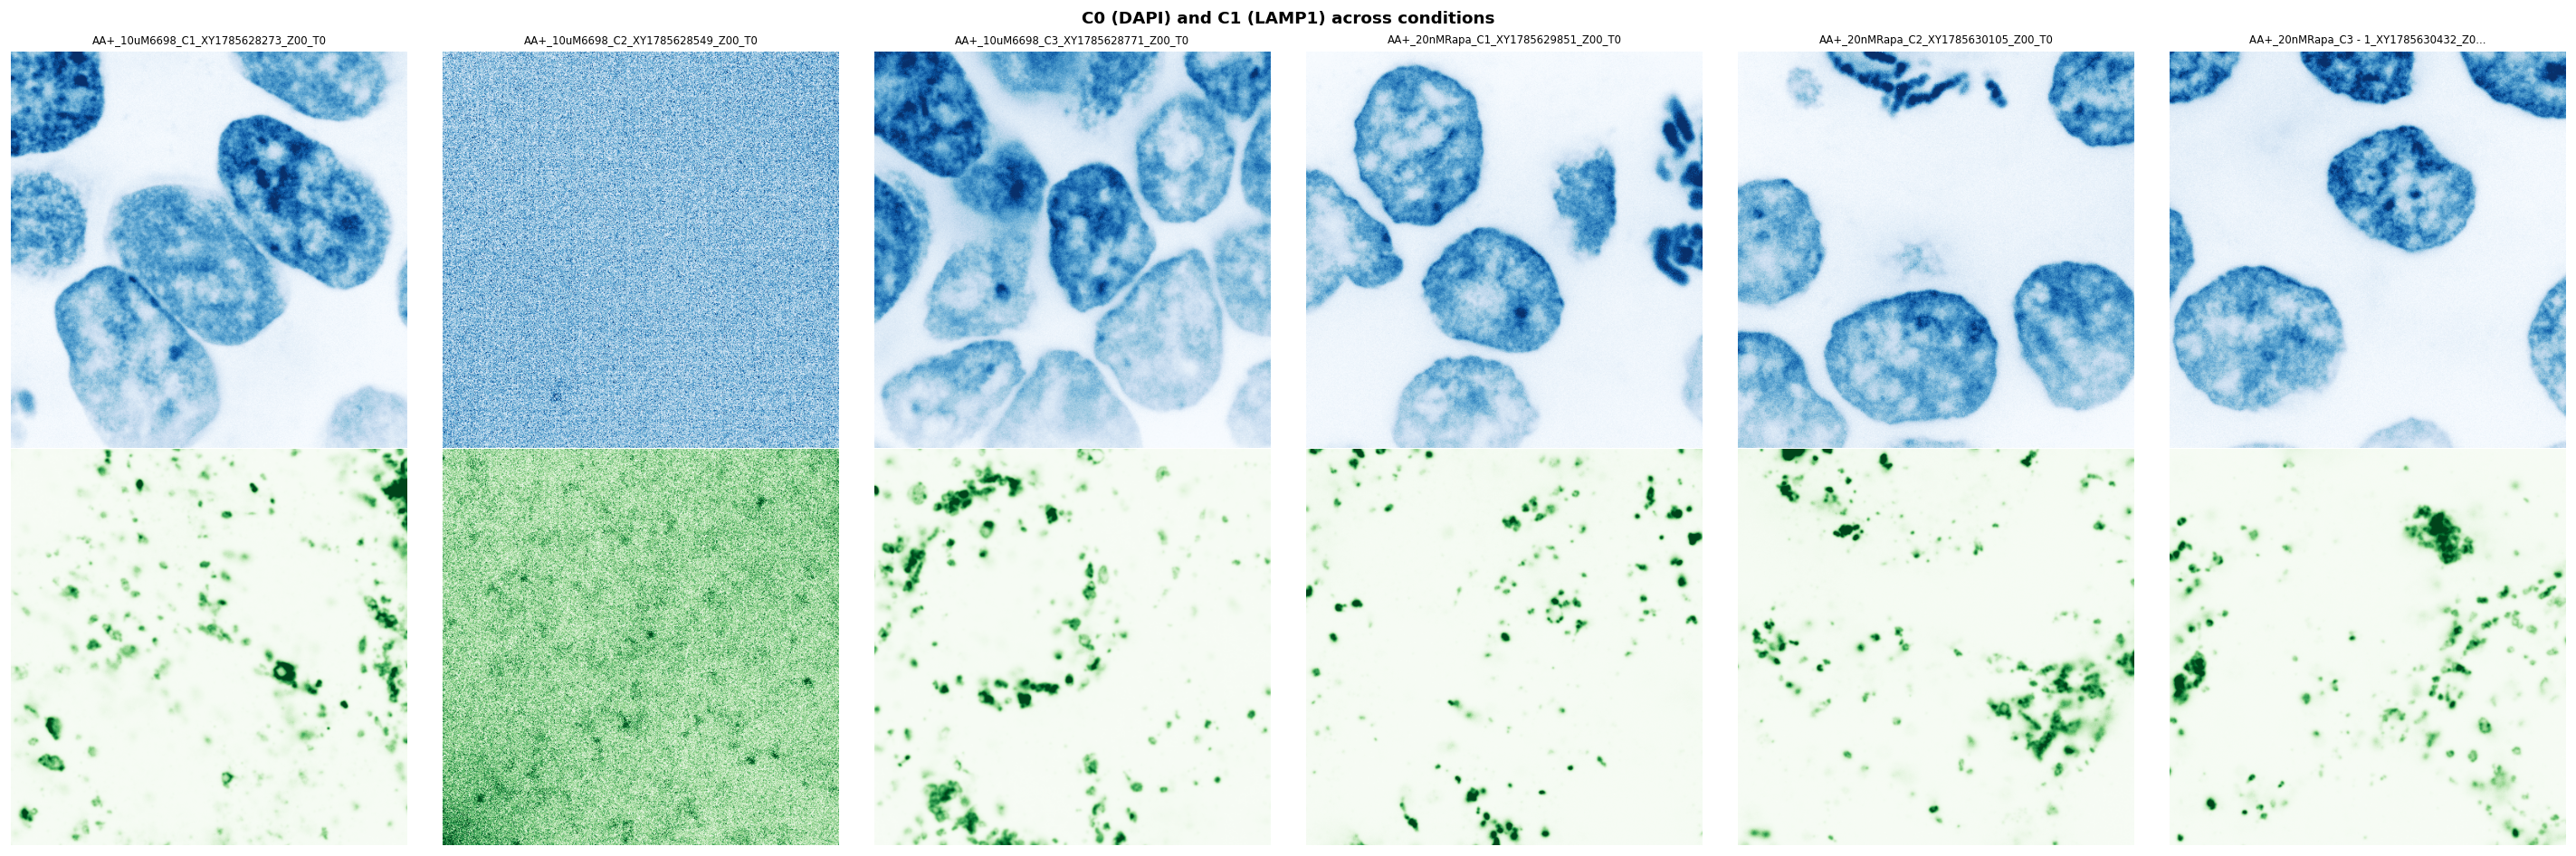

If DAPI (row 1) shows nuclei consistently across all conditions → C0 = DAPI ✓
If LAMP1 (row 2) shows scattered puncta consistently → C1 = LAMP1 ✓


In [9]:
# Compare DAPI channel across several conditions to confirm it's consistent
n_show = min(6, len(triplets))
selected = sorted(triplets.keys())[:n_show]

fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 8))
fig.suptitle(f'C{CH_DAPI} (DAPI) and C{CH_LAMP1} (LAMP1) across conditions',
             fontsize=11, fontweight='bold')

for col, stem in enumerate(selected):
    paths_here = triplets[stem]
    name = Path(stem).name[:35] + '...' if len(Path(stem).name) > 35 else Path(stem).name
    
    # DAPI row
    d = tifffile.imread(paths_here[CH_DAPI]).astype(np.float32)
    d = d[np.argmax([np.var(d[z]) for z in range(d.shape[0])])] if d.ndim==3 else d
    axes[0, col].imshow(norm(d[H//2-256:H//2+256, W//2-256:W//2+256]),
                        cmap='Blues', vmin=0, vmax=1)
    axes[0, col].set_title(name, fontsize=7)
    axes[0, col].axis('off')
    if col == 0:
        axes[0, col].set_ylabel(f'C{CH_DAPI} DAPI', fontsize=9)
    
    # LAMP1 row  
    l = tifffile.imread(paths_here[CH_LAMP1]).astype(np.float32)
    l = l[np.argmax([np.var(l[z]) for z in range(l.shape[0])])] if l.ndim==3 else l
    axes[1, col].imshow(norm(l[H//2-256:H//2+256, W//2-256:W//2+256]),
                        cmap='Greens', vmin=0, vmax=1)
    axes[1, col].axis('off')
    if col == 0:
        axes[1, col].set_ylabel(f'C{CH_LAMP1} LAMP1', fontsize=9)

plt.tight_layout()
plt.show()

print("If DAPI (row 1) shows nuclei consistently across all conditions → C0 = DAPI ✓")
print("If LAMP1 (row 2) shows scattered puncta consistently → C1 = LAMP1 ✓")

## 8. Verdict

In [10]:
# Fill this in after inspecting the images above

CONFIRMED_CH_DAPI   = 0   # ← update if wrong
CONFIRMED_CH_LAMP1  = 1   # ← update if wrong  
CONFIRMED_CH_MARKER = 2   # ← update if wrong

print("═" * 50)
print("CONFIRMED CHANNEL ASSIGNMENTS:")
print(f"  DAPI   = C{CONFIRMED_CH_DAPI}")
print(f"  LAMP1  = C{CONFIRMED_CH_LAMP1}")
print(f"  Raptor = C{CONFIRMED_CH_MARKER}")
print("═" * 50)
print()
print("Run ingest.py with these values:")
print(f"  python ingest.py \\")
print(f'    --image_dir "{IMAGE_DIR}" \\')
print(f"    --layout flat \\")
print(f"    --ch_dapi {CONFIRMED_CH_DAPI} --ch_lamp1 {CONFIRMED_CH_LAMP1} --ch_marker {CONFIRMED_CH_MARKER} \\")
print(f"    --output ~/Desktop/080326_manifest.tsv")

══════════════════════════════════════════════════
CONFIRMED CHANNEL ASSIGNMENTS:
  DAPI   = C0
  LAMP1  = C1
  Raptor = C2
══════════════════════════════════════════════════

Run ingest.py with these values:
  python ingest.py \
    --image_dir "/Users/vaishnavinagesh/Google Drive/My Drive/Confocal/080326" \
    --layout flat \
    --ch_dapi 0 --ch_lamp1 1 --ch_marker 2 \
    --output ~/Desktop/080326_manifest.tsv
